In [2]:
#import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from dadapy import MetricComparisons

#device = 'cpu'
#dtype = torch.float32

KeyboardInterrupt: 

In [2]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

In [ ]:
# Overdamped Langevin step
def ULA_update_faster(states_old, target_energy, n_steps, dt=0.01, temperature=1, friction=1):
    
    '''states_old = states at last update if I use 40 random walkers it has to be made like that:
    states_old = torch.tensor([[pos_rw_1],[pos_rw_2], ..., [pos_rw_40]]),
    target_energy = target energy function,
    n_steps = # of steps to perform, will define the size of the batch,
    dt = time step'''
    
    states_old = states_old.requires_grad_()
    optimizer = torch.optim.SGD([states_old], lr=dt/friction)
    
    # noisy part of Langevin update
    
    def add_noise(grad):
        noise = np.sqrt(2*friction*temperature/dt) * torch.randn_like(grad)
        return grad + noise
    
    states_old.register_hook(add_noise) # adds something to each gradient computed
    
    states_updates = []
    for t in tqdm(range(n_steps)):
        optimizer.zero_grad()
        loss = target_energy(states_old).sum()
        loss.backward()
        optimizer.step()
        states_updates.append(states_old.clone().detach())
    return torch.stack(states_updates)


# energy function
def target_energy_python(states):
    gauss1 = 1/np.sqrt(2*np.pi) * torch.exp(-0.5*((states[0])**2 + (states[1])**2))
    gauss2 = 1/np.sqrt(2*np.pi) * torch.exp(-0.5*((states[0]-3)**2 + (states[1]-3)**2))
    gauss3 = 1/np.sqrt(2*np.pi) * torch.exp(-0.5*((states[0]-9)**2 + states[1]**2))
    energy = -torch.log(1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3)
    return energy
# vectorization using torch.vmap
target_energy = torch.vmap(target_energy_python, in_dims=0, out_dims=0)

In [1]:
states_start = torch.tensor([[0.3,0.3]])
n_steps = 10000
# original parameters: dt = 0.01, friction = 1
traj = ULA_update_faster(states_old=states_start, target_energy=target_energy, n_steps=n_steps, dt=0.01, temperature=1, friction=1)

NameError: name 'np' is not defined

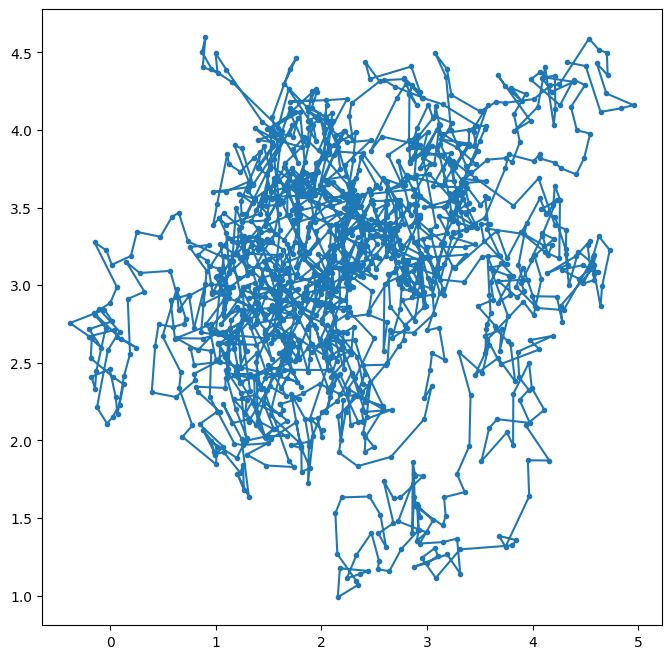

In [12]:
initial_step = 3000
final_step = 4500
samples = np.linspace(initial_step, final_step, 10)
plt.figure(figsize=(8,8))
plt.plot(traj[initial_step:final_step,0,0], traj[initial_step:final_step,0,1], '.-')
plt.show()

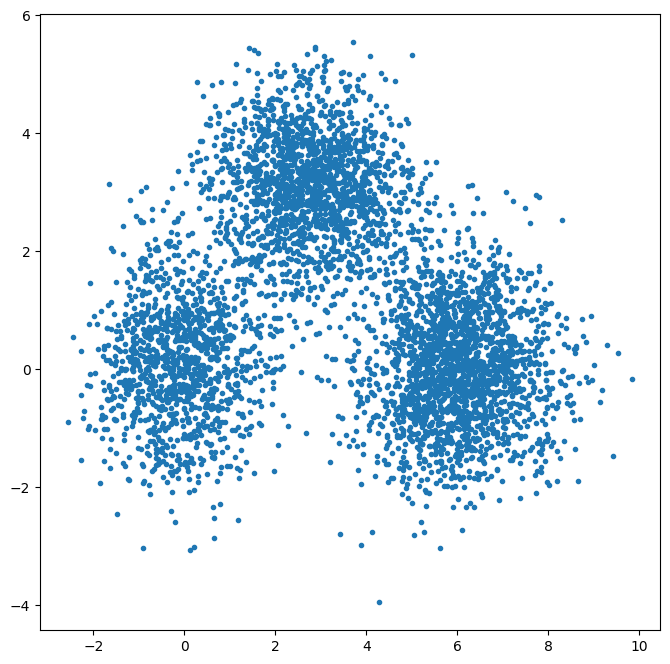

In [30]:
samples = np.linspace(1,100000-1,5000,dtype=int)
plt.figure(figsize=(8,8))
plt.plot(traj[samples,0,0], traj[samples,0,1], '.')
plt.show()

Show autocorrelation

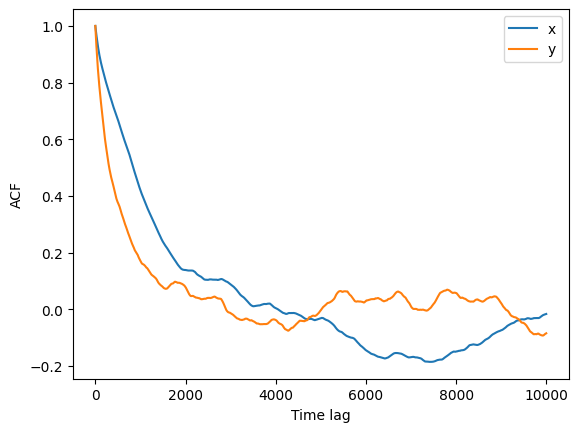

In [31]:
ACFx = autocorr2(np.array(traj[:,0,0]))
ACFy = autocorr2(np.array(traj[:,0,1]))
plt.plot(ACFx[:10000], label="x")
plt.plot(ACFy[:10000], label="y")
plt.legend()
plt.xlabel("Time lag")
plt.ylabel("ACF")
plt.show()

### Check one of generated trajectories

In [11]:
traj = pickle.load(open("./symmetric_energy/pickles_traj/seed0_dt0.01_nsteps10050000_frict1_temp1.p","rb"))
print(traj.shape)

(10050000, 1, 2)


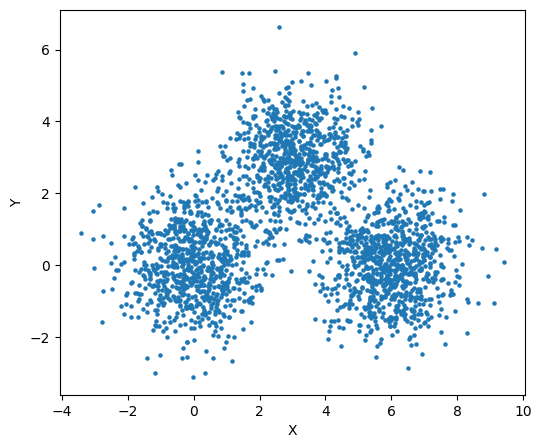

In [4]:
N = 2500
sample_times = np.linspace(50000,10050000-1,N,dtype=int)
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_times,0,0], traj[sample_times,0,1], s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

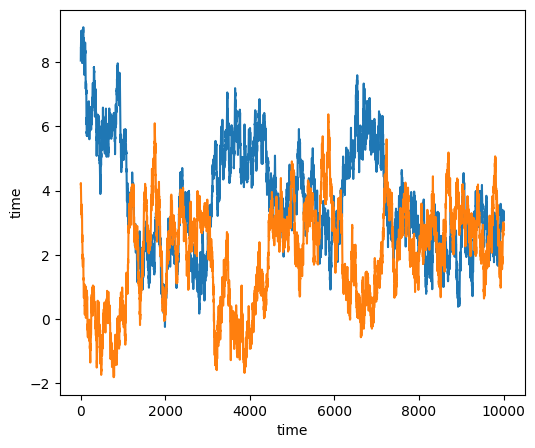

In [13]:
plt.figure(figsize=(6,5))
plt.plot(traj[:10000,0,0], label="X")
plt.plot(traj[:10000,0,1], label="Y")
plt.xlabel("time")
plt.ylabel("time")
plt.show()

In [5]:
# compute information imbalance
d = MetricComparisons(traj[sample_times,0,:])
d.return_inf_imb_two_selected_coords(coords1=[0],coords2=[1])

/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/metric_comparisons.py:65: UserWarning: data type is float64: most methods work only with float-type inputs
  super().__init__(


(0.98539904, 0.95758208)

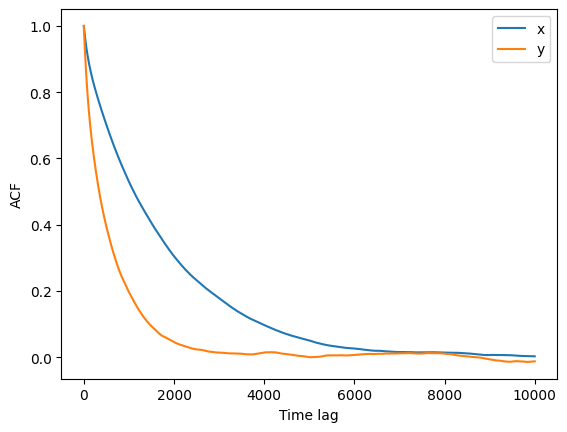

In [8]:
ACFx = autocorr2(np.array(traj[50000:,0,0]))
ACFy = autocorr2(np.array(traj[50000:,0,1]))
plt.plot(ACFx[:10000], label="x")
plt.plot(ACFy[:10000], label="y")
plt.legend()
plt.xlabel("Time lag")
plt.ylabel("ACF")
plt.show()

Autocorrelation time is ~2000, so we can safely sample N = 10^7 / 2000 = 5000 trajectories from a single stationary one. For memory reasons it's better to undersample by a factor 10 the trajectory ---> autocorrelation of order ~200. In this net time units, explore tau up to ~ 100

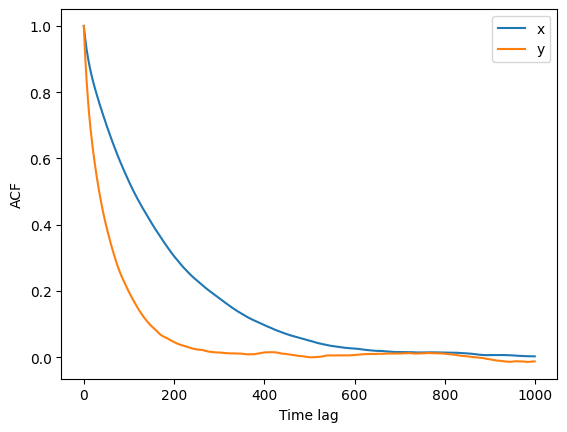

In [5]:
undersample_times = np.arange(50000, traj.shape[0], 10)
ACFx = autocorr2(np.array(traj[undersample_times,0,0]))
ACFy = autocorr2(np.array(traj[undersample_times,0,1]))
plt.plot(ACFx[:1000], label="x") # notice that x range is skrinked by factor 10
plt.plot(ACFy[:1000], label="y")
plt.legend()
plt.xlabel("Time lag")
plt.ylabel("ACF")
plt.show()

### Look at simulations with asymmetric potential

In [7]:
traj = pickle.load(open("./asymmetric_energy/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

(10000, 2500, 2)


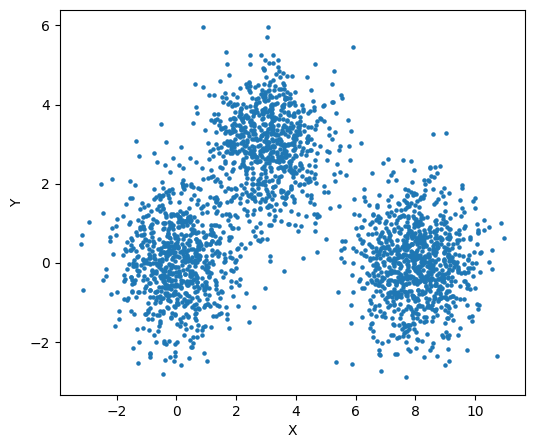

In [11]:
sample_time = 5000
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time,:,0], traj[sample_time,:,1], s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
# compute information imbalance
d = MetricComparisons(traj[sample_time,:,:])
d.return_inf_imb_two_selected_coords(coords1=[0],coords2=[1])

/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/metric_comparisons.py:65: UserWarning: data type is float64: most methods work only with float-type inputs
  super().__init__(


(0.9763263999999999, 0.96818048)

## Compute free energy barriers

1) Between Gaussian $\mathcal{N}((0,0),(1,1))$ and $\mathcal{N}((3,3),(1,1))$ in "symmetric" free enrgy along x. Max of free energy is in (1.5,1.5)

In [12]:
# probability function
def target_prob(states):
    gauss1 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0])**2 + (states[1])**2))
    gauss2 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0]-3)**2 + (states[1]-3)**2))
    gauss3 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0]-6)**2 + states[1]**2))
    return 1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3

# energy function
def target_energy(states):
    energy = -np.log(target_prob(states))
    return energy

prob_ratio1 = target_prob([1.5,1.5]) / target_prob([0,0])
prob_ratio2 = target_prob([1.5,1.5]) / target_prob([3,3])
print(prob_ratio1, prob_ratio2)

eng_barrier1 = target_energy([1.5,1.5]) - target_energy([0,0])
eng_barrier2 = target_energy([1.5,1.5]) - target_energy([3,3])
print(eng_barrier1, eng_barrier2)

0.2107854402212427 0.21075943685975818
1.556914533859504 1.5570379055949055


2) Try to construct three gaussian with energy barriers of ~5 kB T.
Between Gaussian $\mathcal{N}((0,0),(1,1))$ and $\mathcal{N}((3,3),(1,1))$ in "symmetric" free enrgy along x. Max of free energy is in (1.5,1.5)

In [20]:
# probability function
def target_prob(states):
    gauss1 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0])**2 + (states[1])**2))
    gauss2 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0]-5)**2 + (states[1]-5)**2))
    gauss3 = 1/np.sqrt(2*np.pi) * np.exp(-0.5*((states[0]-10)**2 + states[1]**2))
    return 1/3*gauss1 + 1/3*gauss2 + 1/3*gauss3

# energy function
def target_energy(states):
    energy = -np.log(target_prob(states))
    return energy

prob_ratio1 = target_prob([2.5,2.5]) / target_prob([0,0])
prob_ratio2 = target_prob([2.5,2.5]) / target_prob([5,5])
print(prob_ratio1, prob_ratio2)

eng_barrier1 = target_energy([2.5,2.5]) - target_energy([0,0])
eng_barrier2 = target_energy([2.5,2.5]) - target_energy([5,5])
print(eng_barrier1, eng_barrier2)

0.003860908272428608 0.003860908272374988
5.556852819446998 5.556852819460886


In [19]:
-np.log(0.01)

4.605170185988091

### Simulations with diagonal wells

Close wells

In [8]:
traj = pickle.load(open("./diagonal_wells_close/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

(10000, 2500, 2)


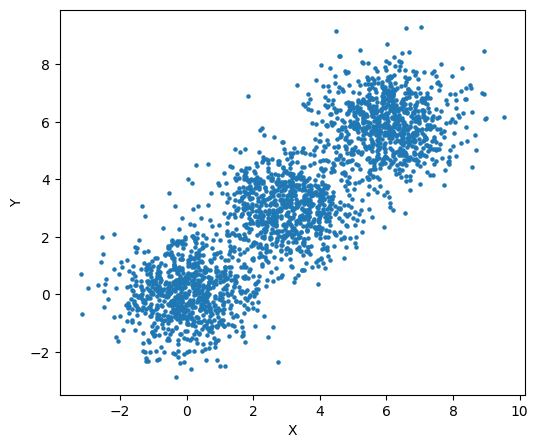

In [5]:
sample_time = 5000
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time,:,0], traj[sample_time,:,1], s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Far wells

In [4]:
traj = pickle.load(open("./diagonal_wells_far/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

(10000, 2500, 2)


In [5]:
sample_time = 5000
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time,:,0], s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

TypeError: scatter() missing 1 required positional argument: 'y'

<Figure size 600x500 with 0 Axes>

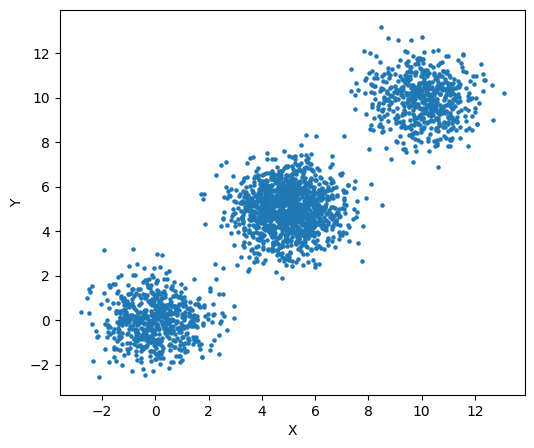

In [ ]:
sample_time = 5000
plt.figure(figsize=(6,5))
plt.plot()
plt.xlabel("time")
plt.ylabel("X")
plt.show()

Far wells, symmetric along x

In [3]:
traj = pickle.load(open("./symmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

(10000, 2500, 2)


In [5]:
# compute information imbalance
d = MetricComparisons(traj[sample_time,:,:], maxk=2500-1)
d.return_inf_imb_two_selected_coords(coords1=[0],coords2=[1])

(0.5829814400000001, 0.78028416)

Far wells, asymmetric along x

In [11]:
traj = pickle.load(open("./asymmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

(10000, 2500, 2)


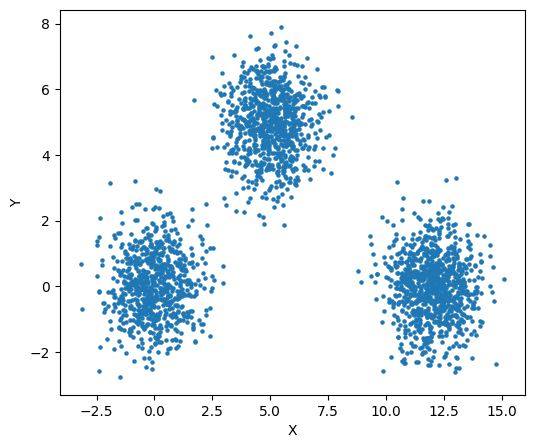

In [12]:
sample_time = 5000
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time,:,0], traj[sample_time,:,1], s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [20]:
# compute information imbalance
d = MetricComparisons(traj[sample_time,:,:], maxk=2500-1)
d.return_inf_imb_two_selected_coords(coords1=[0],coords2=[1])

/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/metric_comparisons.py:65: UserWarning: data type is float64: most methods work only with float-type inputs
  super().__init__(


(0.96902848, 0.95829984)

### Convert continuous traj into discrete

In [12]:
def from_continuous_to_discrete_traj(traj):
    centers_x = np.array([0.0,5.0,10.0])
    centers_y = np.array([0.0,5.0,10.0])

    traj_discrete_x = np.argmin(np.abs(traj[:,:,0,np.newaxis] - centers_x[np.newaxis,np.newaxis,:]), axis=-1)
    traj_discrete_y = np.argmin(np.abs(traj[:,:,1,np.newaxis] - centers_y[np.newaxis,np.newaxis,:]), axis=-1)

    return np.concatenate((traj_discrete_x[:,:,np.newaxis],traj_discrete_y[:,:,np.newaxis]), axis=-1)

In [13]:
traj = pickle.load(open("./diagonal_wells_far/pickles_traj/seed0_N2500_dt0.01_nsteps10000_frict1_temp1.p","rb"))
print(traj.shape)

traj_discrete = from_continuous_to_discrete_traj(traj)
print(traj_discrete.shape)

(10000, 2500, 2)
(10000, 2500, 2)


True
True


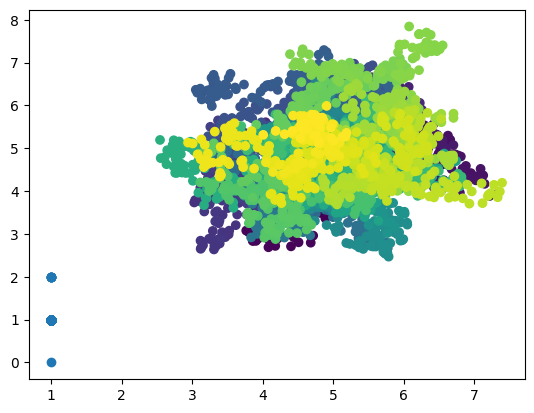

In [34]:
trial_traj = 1
start=5000
stop=9000

plt.scatter(traj[start:stop,trial_traj,0], traj[start:stop,trial_traj,1], c=np.arange(start,stop))
plt.scatter(traj_discrete[start:stop,trial_traj,0], traj_discrete[start:stop,trial_traj,1])


print(((traj[start:stop,trial_traj,1] - 2.5)<0).any())
print(((7.5 - traj[start:stop,trial_traj,1])<0).any())

### Long trajectory to visualize transition, symmetric energy with far wells

In [31]:
traj = pickle.load(open("./symmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb"))
print(traj.shape)

FileNotFoundError: [Errno 2] No such file or directory: './symmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p'

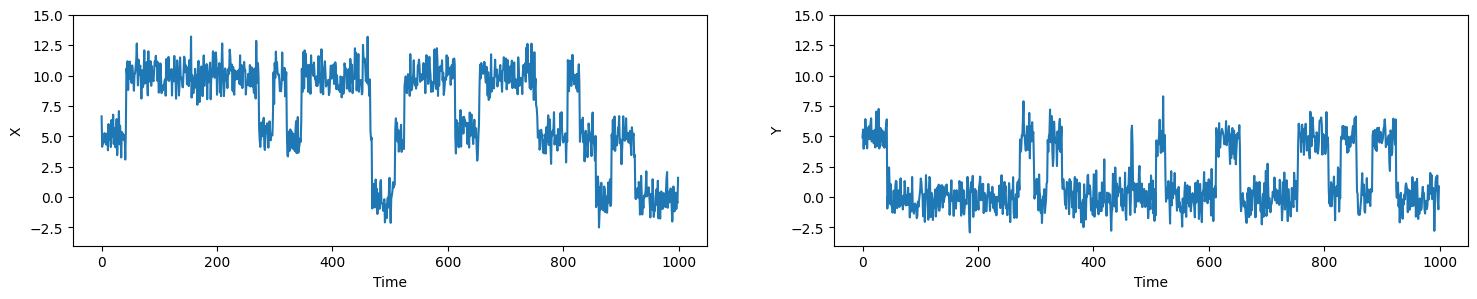

<Figure size 1200x400 with 0 Axes>

In [26]:
fig, ax = plt.subplots(1,2,figsize=(18,3))
plt.figure(figsize=(12,4))
ax[0].plot(traj[:,0,0])
ax[1].plot(traj[:,0,1])
ax[0].set(xlabel="Time", ylabel="X",ylim=[-4,15])
ax[1].set(xlabel="Time", ylabel="Y",ylim=[-4,15])
plt.show()

Same with asymmetric potential

In [3]:
traj = pickle.load(open("./asymmetric_energy_far/pickles_traj/seed0_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb"))
print(traj.shape)

(1000, 2500, 2)


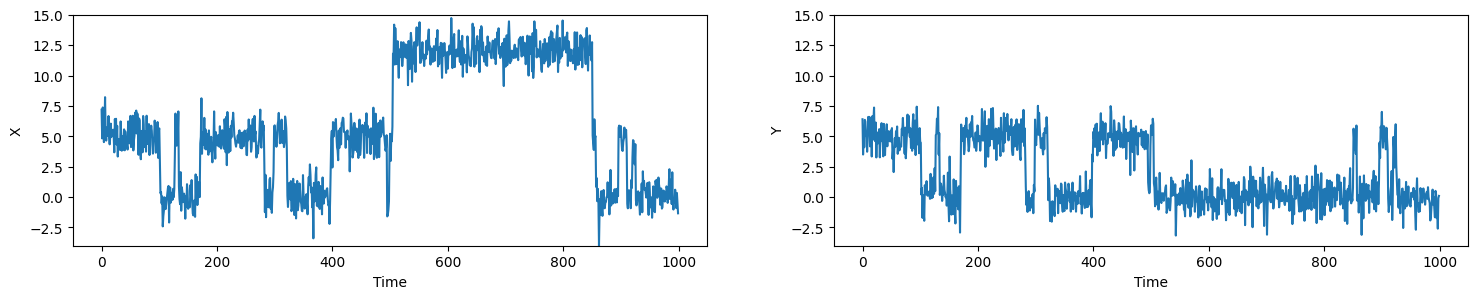

<Figure size 1200x400 with 0 Axes>

In [4]:
fig, ax = plt.subplots(1,2,figsize=(18,3))
plt.figure(figsize=(12,4))
ax[0].plot(traj[:,0,0])
ax[1].plot(traj[:,0,1])
ax[0].set(xlabel="Time", ylabel="X",ylim=[-4,15])
ax[1].set(xlabel="Time", ylabel="Y",ylim=[-4,15])
plt.show()

Scatter plot with lags between X and Y variables

In [8]:
sample_time = 100
tau = 50

# X(0) vs Y(tau)
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time,:,0], traj[sample_time+tau,:,1], s=5)
plt.xlabel("$X(0)$")
plt.ylabel("$Y(\\tau)$")
plt.show()

# X(tau) vs Y(0)
plt.figure(figsize=(6,5))
plt.scatter(traj[sample_time+tau,:,0], traj[sample_time,:,1], s=5)
plt.xlabel("$X(\\tau)$")
plt.ylabel("$Y(0)$")
plt.show()

### Check for asymmetries in velocities, in case of symmetric FES with different friction coefficients

In [4]:
f = open("/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed/pickles_traj/seed0_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_temp1.p","rb")
data = pickle.load(f)

print(data.shape)
data = data.reshape((-1,2))
print(data.shape)

(2000, 2500, 2)
(5000000, 2)


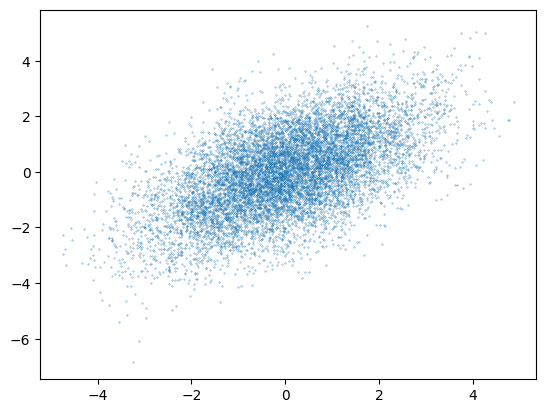

In [9]:
samples = np.linspace(0,5000000-2,10000,dtype=int)
plt.plot(data[samples+1,0]-data[samples,0], 
         data[samples+1,1]-data[samples,1], '.', markersize=0.5)

### Check for asymmetries in velocities, in case of symmetric FES with same friction coefficients

In [ ]:
f = open("/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed/pickles_traj/seed0_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_temp1.p","rb")
data = pickle.load(f)

print(data.shape)
data = data.reshape((-1,2))
print(data.shape)

(2000, 2500, 2)
(5000000, 2)


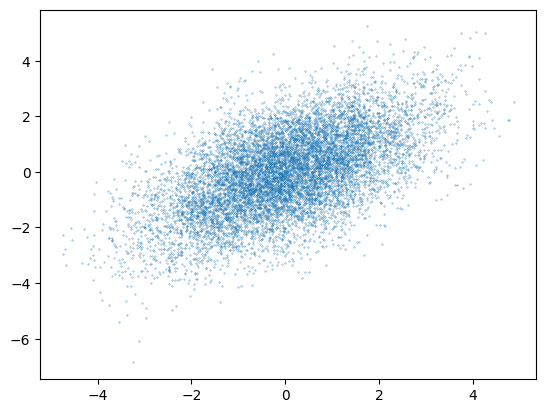

In [ ]:
samples = np.linspace(0,5000000-2,10000,dtype=int)
plt.plot(data[samples+1,0]-data[samples,0], 
         data[samples+1,1]-data[samples,1], '.', markersize=0.5)